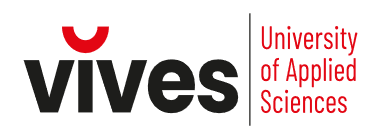<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **LINEAR CLASSIFICATION: INTRODUCTION**

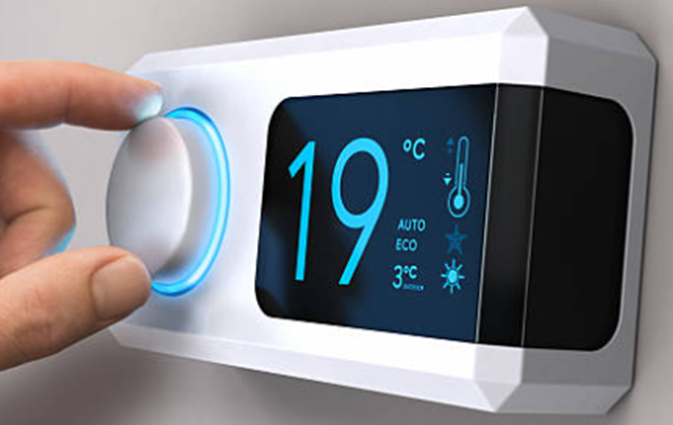

## Thermostat dataset

Read dataset

In [2]:
import pandas as pd

df = pd.read_csv("thermostat.csv")
df.head()

,temperature,heating
0,19.5,off
1,21.2,off
2,20.0,off
3,19.4,off
4,18.2,on


Explore dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  100 non-null    float64
 1   heating      100 non-null    object 
dtypes: float64(1), object(1)
memory usage: 1.7+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,100.0,18.729,2.900028,14.0,16.075,18.7,20.825,23.9


In [7]:
print(df.heating.unique())  # binary target

['off' 'on']


Scale temperature and convert heating into binary variable

In [8]:
df["temperature_scaled"] = (df["temperature"] - 14) / (24 - 14)  # min-max scaling
df["heating_on"] = (df.heating=="on").astype(int)  # convert to binary variable
df.head()

,temperature,heating,temperature_scaled,heating_on
0,19.5,off,0.55,0
1,21.2,off,0.72,0
2,20.0,off,0.60,0
3,19.4,off,0.54,0
4,18.2,on,0.42,1


Create scatter plot

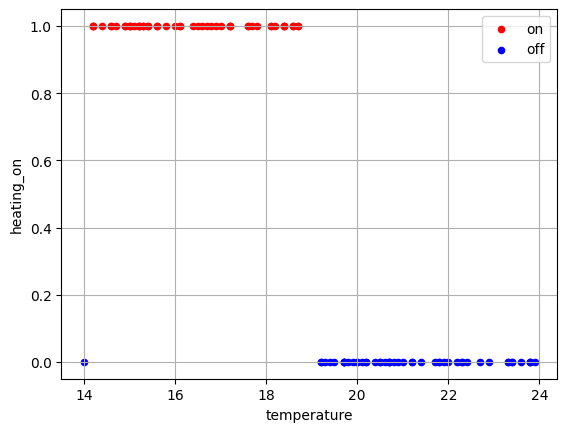

In [9]:
import matplotlib.pyplot as plt

def plot_data(scaled=False):
    x = "temperature_scaled" if scaled else "temperature"
    ax = df[df.heating_on==1].plot.scatter(x=x, y="heating_on",
                                           color="red", label="on");
    df[df.heating_on==0].plot.scatter(x=x, y="heating_on",
                                      color="blue", ax=ax, label="off");
    plt.legend();
    plt.grid();
    return ax

plot_data();

The outlier is probably an observation error - correct it

In [10]:
i = df.temperature.argmin()
df.loc[i, ["heating", "heating_on"]] = ["on", 1]

Plot the data again to verify

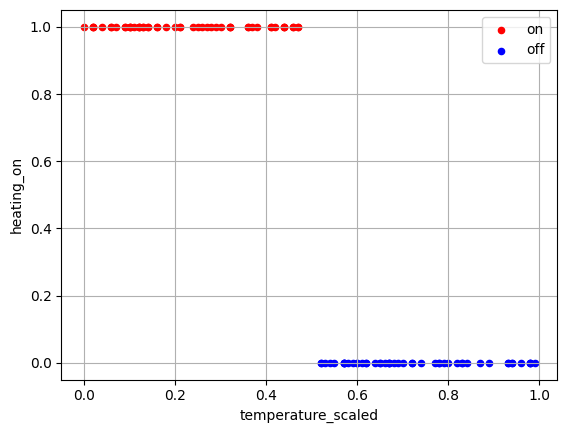

In [11]:
plot_data(True);

Check whether the dataset is balanced

In [13]:
print(df.heating_on.sum() / len(df))  # 51% heating on

0.51


## Linear regression

Fit the data using simple linear regression

In [14]:
from sklearn.linear_model import LinearRegression

X = df[["temperature"]].values
y = df["heating_on"].values

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.score(X, y)  # R²

0.7483026124461083

Plot the regression line

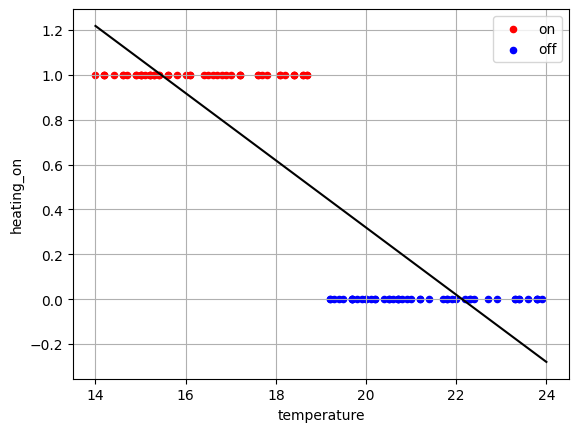

In [15]:
import numpy as np

x_line = np.array([14, 24])
y_line = lin_reg.predict(x_line[:, np.newaxis])
ax = plot_data()
ax.plot(x_line, y_line, 'k-');

Doesn't make any sense because regression predicts numerical values while we need to predict labels because our target is a categorical variable (binary classification problem).

## Perceptron

The perceptron model predicts 1 or 0

In [16]:
from sklearn.linear_model import Perceptron

perc = Perceptron()
perc.fit(X, y)
perc.score(X, y)  # accuracy

0.49

The model doesn't train: use scaled temperature and change learning rate!

In [17]:
Xs = df[["temperature_scaled"]].values

perc = Perceptron(eta0=1e-4,        # learning rate
                  max_iter=10_000)  # maximum number of epochs
perc.fit(Xs, y)
perc.score(Xs, y)  # accuracy

1.0

Similar to linear regression, the perceptron model also applies a linear transformation of the input features

> $z = ax + b$

with $z$ the scores or logits.

In [18]:
a, b = perc.coef_.item(), perc.intercept_.item()
a, b

(-0.00020699999999999996, 0.0001)

The perceptron predicts the label as follows:

> $z \ge 0 \rightarrow \hat{y} = 1$
>
> $z \lt 0 \rightarrow \hat{y} = 0$

Mathematically this is done by transforming $z$ using the Heaviside step function $H$, which is an activation function

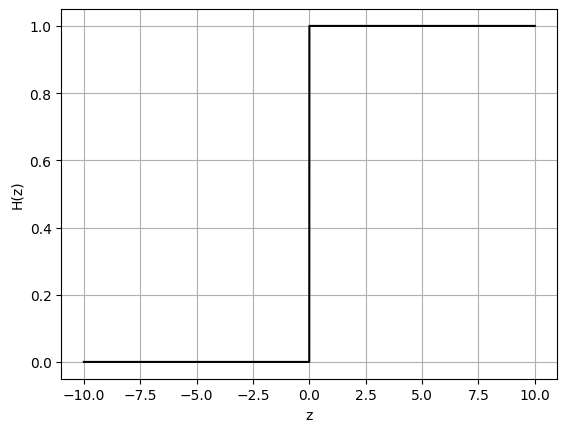

In [19]:
H = lambda z: (z >= 0).astype(int)  # step function

z = np.linspace(-10, 10, 10000)
plt.plot(z, H(z), 'k-');
plt.grid();
plt.xlabel("z");
plt.ylabel("H(z)");

The threshold is found by solving $z = 0$

In [20]:
# solve z = a X + b = 0
threshold = -b / a
threshold

0.4830917874396136

Scale threshold back to get temperature

In [21]:
# temperature threshold
threshold * (24 - 14) + 14

18.830917874396135

Plot the fitted perceptron model (black) and the threshold (green)

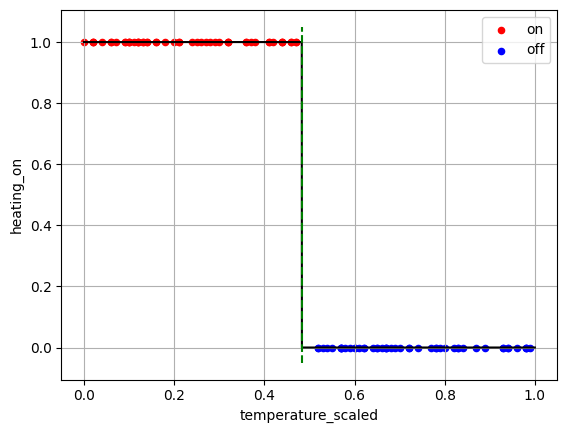

In [22]:
ax = plot_data(True)
x = np.linspace(0, 1, 10000)
ax.plot(x, H(a * x + b), "k-");
ax.plot([threshold, threshold], ax.get_ylim(), 'g--');

Show how predictions are made and calculate accuracy

In [23]:
z = a * Xs.squeeze() + b  # logits
y_pred = H(z)             # predicted labels
print(np.sum(y_pred == y) / len(y))  # accuracy

1.0


## Logistic Regression

Logistic regression predicts the probability that the sample has a positive label

In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)
log_reg.score(X, y)  # accuracy

1.0

Logistic regression also applies a linear transformation

> $z = ax + b$

In [25]:
a, b = log_reg.coef_.item(), log_reg.intercept_.item()
a, b

(-2.6534715889172773, 50.26173510098823)

Instead of applying the step function, logistic regression uses the sigmoid function $\sigma$ to transform score $z$ into a probability

> $\sigma(z) = \dfrac{1}{1+e^{-z}}$

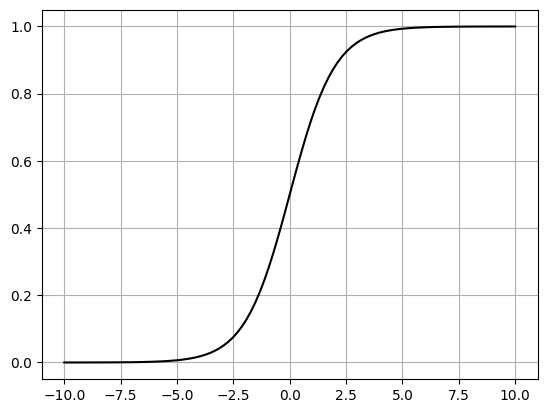

In [26]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))  # sigmoid function

x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x), 'k-');
plt.grid();

The threshold is found by solving $z = 0$, which corresponds to $\sigma(z=0)=0.5$, or a probability of 50% the label equals 1

In [27]:
# solve a x + b = 0
threshold = -b / a
threshold

18.941877995195355

Plot the logistic regression model (black) and the threshold (green)

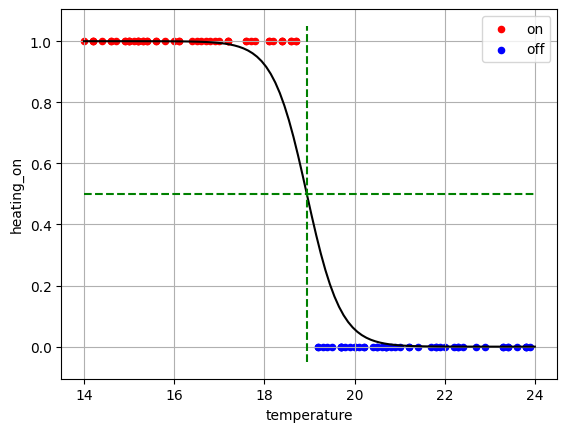

In [28]:
x = np.linspace(14, 24, 100)
ax = plot_data()
ax.plot(x, sigmoid(a*x + b), 'k-');
ax.plot([threshold, threshold], ax.get_ylim(), 'g--');
ax.plot([14, 24], [0.5, 0.5], 'g--');

Show how probabilities are calculated and rounded to get the predicted labels. Use these predicted labels to calculate the accuracy.

In [29]:
z = a * X.squeeze() + b              # logits
y_proba = sigmoid(z)                 # predicted probabilities
y_pred = np.round(y_proba)           # predicted labels
print(np.sum(y_pred == y) / len(y))  # accuracy

1.0


Logistic regression minimizes the log loss or binary crossentropy:

- if the true label $y_i$ is positive, then the error equals $-\ln(\hat{p}_i)$
- if the true label $y_i$ is negative, then the error equals $-\ln(1-\hat{p}_i)$

with $\hat{p}$ the predicted probability that the label is positive, and $1-\hat{p}$ the predicted probability that the label is negative


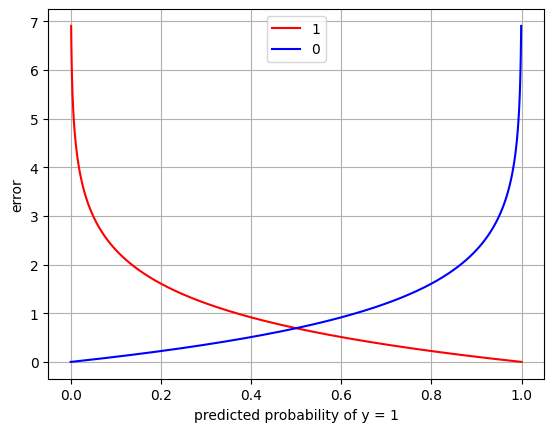

In [30]:
def plot_error():
    p = np.logspace(-3, 0, 100)
    plt.plot(p, -np.log(p), 'r-', label="1")
    p = 1 - p
    plt.plot(p, -np.log(1-p), 'b-', label="0")
    plt.legend()
    plt.grid();
    plt.xlabel('predicted probability of y = 1');
    plt.ylabel('error');

plot_error()

Add the errors of the data points to the plot

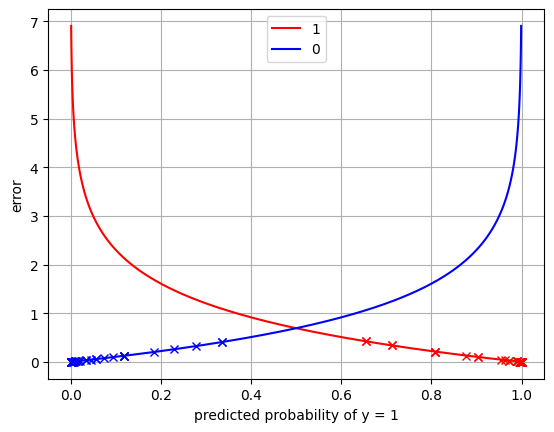

In [31]:
plot_error()

# true positive labels
b = y==1
plt.plot(y_proba[b], -np.log(y_proba[b]), 'rx');

# true negative labels
b = y==0
plt.plot(y_proba[b], -np.log(1-y_proba[b]), 'bx');

Use single formula to calculate error:

> $- y_i \ln(\hat{p}_i) - (1-y_i) \ln(1-\hat{p}_i)$

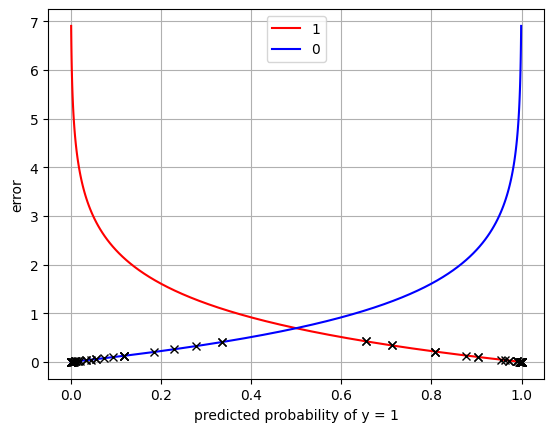

In [32]:
plot_error()
error = y * -np.log(y_proba) + (1 - y) * -np.log(1 - y_proba)
plt.plot(y_proba, error, 'kx');

Log loss or binary cross-entropy is the mean error of all data points

In [33]:
log_loss = -np.mean(y * np.log(y_proba) + (1 - y) * np.log(1 - y_proba))
print(log_loss)

0.053247116696651754


## Neural network

Logistic regression can be applied using a neural net with a single neuron! We define:

- "sigmoid" as activation function
- "binary_crossentropy" as loss function

We use stochastic gradient descent (SGD) as optimizer and "accuracy" as evaluation metric.

In [34]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

nn = Sequential()
nn.add(Dense(1, activation="sigmoid"))
nn.compile(loss="binary_crossentropy",
           optimizer=SGD(learning_rate=0.5),
           metrics=["accuracy"])
result = nn.fit(Xs, y, epochs=200, verbose=0);

log_loss, acc = nn.evaluate(Xs, y, verbose=0)
print(acc)

1.0


Plot of log loss vs epoch

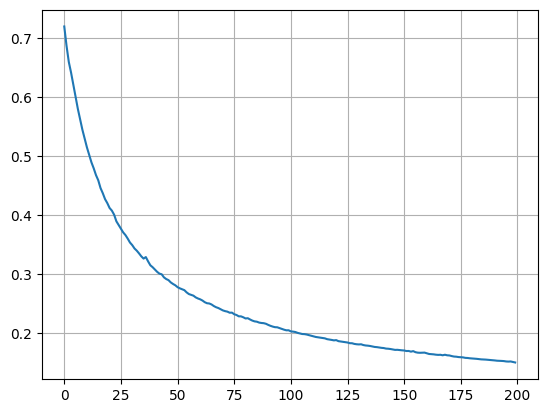

In [35]:
plt.plot(result.history['loss']);
plt.grid();

## Thermostat dataset with two features

Read dataset

In [36]:
df = pd.read_csv("thermostat2.csv", sep=";")
df.head()

,temperature,window,# people,heating
0,19.5,closed,1.0,off
1,21.2,closed,NaN,off
2,20.0,closed,NaN,off
3,19.4,closed,NaN,off
4,18.2,closed,5.0,off


Explore dataset

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  100 non-null    float64
 1   window       100 non-null    object 
 2   # people     29 non-null     float64
 3   heating      100 non-null    object 
dtypes: float64(2), object(2)
memory usage: 3.3+ KB


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,100.0,18.72900,2.900028,14.0,16.075,18.7,20.825,23.9
# people,29.0,1.62069,1.801067,0.0,0.000,1.0,3.000,5.0


Features and target:
- number of people is not used as it contains too many missing values
- temperature is scaled (min-max scaling)
- window and heating are converted into binary variables

In [39]:
df["temperature_scaled"] = (df["temperature"] - 14) / (24 - 14)  # x1
df["window_open"] = (df.window == "open").astype(int)            # x2
df["heating_on"] = (df.heating == "on").astype(int)              # y

Verify whether the dataset is balanced

In [40]:
print(df.heating_on.sum() / len(df))  # 42% positive labels

0.42


Scatter plot - problem is 2D now!

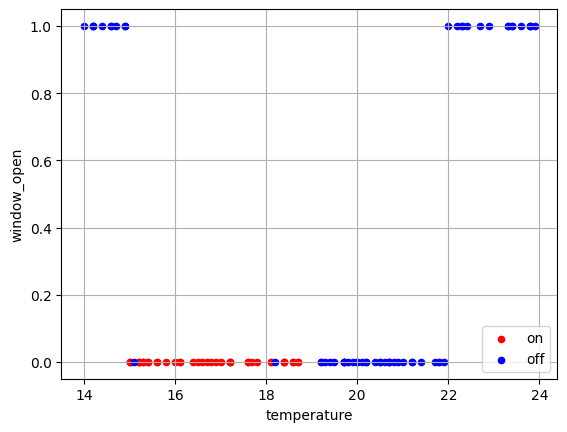

In [41]:
def plot_data(scaled=False):
    x = "temperature_scaled" if scaled else "temperature"
    ax = df[df["heating_on"]==1].plot.scatter(x=x, y="window_open",
                                              color="red", label="on")
    df[df["heating_on"]==0].plot.scatter(x=x, y="window_open",
                                         ax=ax, color="blue", label="off")
    plt.legend()
    plt.grid()
    return ax

plot_data();

Train logistic regression model

In [42]:
X = df[["temperature", "window_open"]].values
y = df["heating_on"].values

log_reg = LogisticRegression()
log_reg.fit(X, y)
log_reg.score(X, y)  # acc

0.91

Training the model using the scaled temperature gives a better result!

In [43]:
Xs = df[["temperature_scaled", "window_open"]].values
y = df["heating_on"].values

log_reg = LogisticRegression()
log_reg.fit(Xs, y)
log_reg.score(Xs, y)  # acc

0.95

The logits are calculated as follows:

> $z = w_1 x_1 + w_2 x_2 + b$

In [44]:
w1, w2 = tuple(log_reg.coef_[0])
b = log_reg.intercept_[0]

The decision boundary is a straight line which is found by solving $z=0$ or:

> $w_1 x_1 + w_2 x_2 + b = 0$

which gives:

> $x_2 = -\dfrac{w_1 x_1+b}{w_2}$

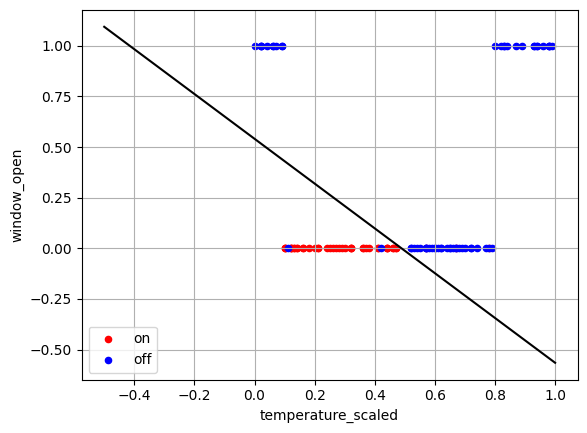

In [45]:
plot_data(True);
x_line = np.linspace(-0.5, 1)
y_line = -(w1*x_line + b) / w2
plt.plot(x_line, y_line, 'k-');

Show how predicted labels are calculated and used to determine accuracy

In [46]:
z = np.dot(Xs, [w1, w2]) + b  # logits
y_proba = sigmoid(z)          # predicted probabilities
y_pred = np.round(y_proba)    # predicted labels
print(np.sum(y_pred == y) / len(y))  # accuracy

0.95


Contourplot of 2D logistic regression model with decision boundary (black line)

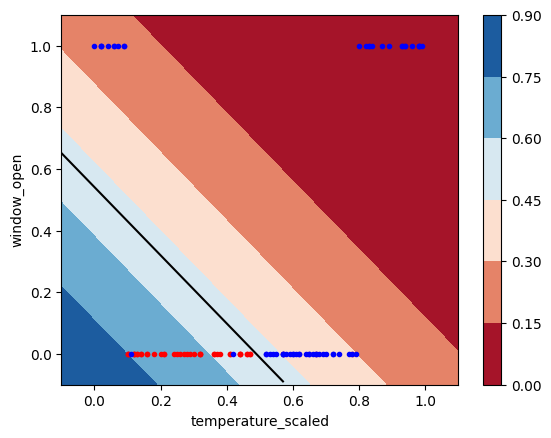

In [47]:
g = np.linspace(-0.1, 1.1, 100)
X_plot, Y_plot = np.meshgrid(g, g)
Z_plot = sigmoid(w1*X_plot + w2*Y_plot + b)
plt.contourf(X_plot, Y_plot, Z_plot, cmap="RdBu");
plt.colorbar();
plt.plot(Xs[y==1, 0], Xs[y==1, 1], 'r.');
plt.plot(Xs[y==0, 0], Xs[y==0, 1], 'b.');
x_line = np.linspace(-0.1, 0.57)
plt.plot(x_line, -(w1*x_line + b) / w2, 'k-');
plt.xlabel("temperature_scaled");
plt.ylabel("window_open");

3D plot of 2D logistic regression model

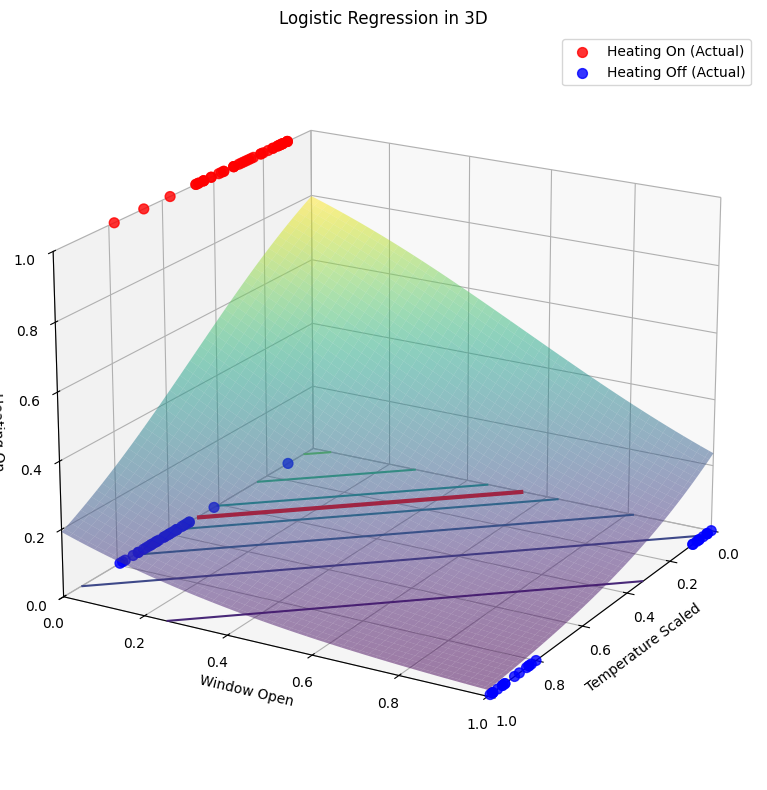

In [48]:
from mpl_toolkits.mplot3d import Axes3D

# Generate a meshgrid for temperature_scaled and window_open
temp_scaled_range = np.linspace(-0.5, 1.5, 100)
temp_scaled_range = np.linspace(0, 1, 100)
window_open_range = np.linspace(0, 1, 100)
X_mesh_temp, X_mesh_window = np.meshgrid(temp_scaled_range, window_open_range)

# Flatten the meshgrid for probability calculation
X_mesh_flat = np.c_[X_mesh_temp.ravel(), X_mesh_window.ravel()]

# Calculate the probability of heating_on for each point in the meshgrid
Z_proba = sigmoid(np.dot(X_mesh_flat, [w1, w2]) + b)
Z_proba = Z_proba.reshape(X_mesh_temp.shape)

# Create a figure and a 3D subplot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the probability surface with transparency
ax.plot_surface(X_mesh_temp, X_mesh_window, Z_proba, cmap='viridis', alpha=0.5)

# Add contour lines projected on the XY plane (z = 0)
ax.contour(X_mesh_temp, X_mesh_window, Z_proba,
    zdir='z',          # project along z-axis
    offset=0,          # project onto z = 0 plane
    levels=np.linspace(0, 1, 10),  # probability levels
    cmap='viridis'
)

# Add decision boundary
ax.contour(X_mesh_temp, X_mesh_window, Z_proba,
           zdir='z', offset=0, levels=[0.5], colors='red', linewidths=3)

# Plot original data points
ax.scatter(Xs[y==1, 0], Xs[y==1, 1], y[y==1], color='red', label='Heating On (Actual)', s=50, alpha=0.8)
ax.scatter(Xs[y==0, 0], Xs[y==0, 1], y[y==0], color='blue', label='Heating Off (Actual)', s=50, alpha=0.8)

# Set limits, view, labels and title
ax.set_xlabel('Temperature Scaled')
ax.set_ylabel('Window Open')
ax.set_zlabel('Heating On')
ax.set_title('Logistic Regression in 3D')
ax.legend()
ax.view_init(elev=20, azim=30)
ax.set_xlim((0, 1))
ax.set_ylim((0, 1))
ax.set_zlim((0, 1))
plt.tight_layout()
plt.show()

---